# Tutorial: create pointcloud from images

This notebook illustrates the process of creating point cloud from images.

<span style="background-color: #FFFF00">Note</span>
All point cloud will be sampled from the black pixel regions of an image. 

In [53]:
using Pkg
Pkg.activate("../.")
Pkg.instantiate()

  Activating project at `~/Documents/TDA_on_lung_ECM`


In [54]:
include("../src/preprocess.jl") # note: the preprocess.jl is separated from ECM_TDA.jl due to dependency issues
using .preprocess

using Images
using CSV
using Plots
using Random
using StatsBase
using Distributions
using DataFrames

gr()
c_ECM = "#259ea1"


"#259ea1"

# 1. Creating point cloud from a single image

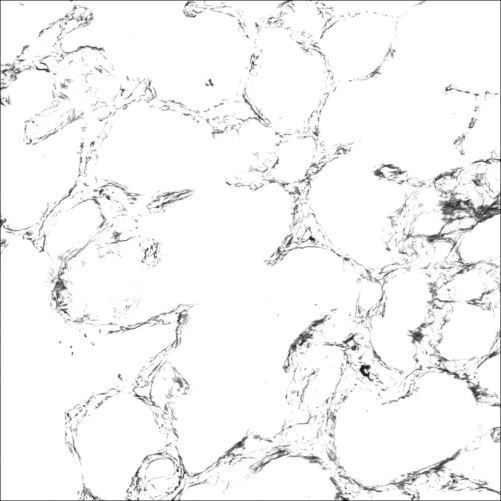

In [56]:
# load image
image_path = "example_images/ECM_example1.tif"
img = Array(Images.load(image_path))


In [57]:
resampled, points, sampled, island_idx = sample_ECM_points(img, vicinity = 100, n_points = 5)

([3892 2347; 1221 1604; … ; 3570 707; 1110 3990], [1 564; 1 565; … ; 4000 3930; 4000 3931], Bool[0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 1 0], Any[1455, 5309, 6149, 7199, 8631, 9152, 10268, 10798, 17285, 24893  …  154443, 168103, 168172, 180195, 183352, 189664, 195903, 201429, 218068, 257575])

* `resampled` is the point cloud that is used for computing topological features. The other outputs are used solely to visualize the sampling process.

<b> Sampling point cloud </b>
1. For each pixel in the image with pixel value `p`, sample a point from Binomial(p^2). The result is `points`
2.  Remove "island" points: points that have less than M points in its neighborhood, as indicated by `island_idx`. 
3. Downsample. The final output is `resampled`

The parameters `vicinity` and `n_points` are used to determine whether a sampled point is an "island" point that is far from everything else.

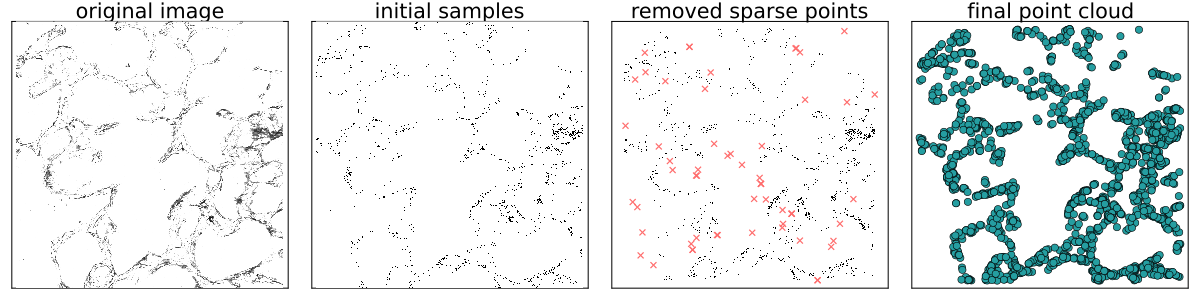

In [58]:
gr()
p1 = plot(Gray.(img), frame = :box, ticks = [], title = "original image")
p2 = plot(Gray.(1 .- sampled), frame = :box, ticks = [], title = "initial samples")
p3 = plot(Gray.(1 .- sampled), frame = :box, ticks = [], title = "removed sparse points")
scatter!(p3, points[island_idx,1], points[island_idx,2], yflip = :true, c = "#ff6b6b", label = "", frame = :box, ticks = [], markershape = :xcross, markersize = 3, markerstrokewidth = 2)
p4 = scatter(resampled[:,1], resampled[:,2], yflip = :true, c = c_ECM, label = "", frame = :box, ticks = [], title = "final point cloud")
p = plot(p1, p2, p3, p4, layout = grid(1,4), size = (1200, 300), background_color=:transparent, foreground_color=:black)
plot(p)
#savefig("figures/sampling_process.png")

# 2. Creating point clouds for multiple images in a directory

* Determine the number of points to sample from each ECM image based on mean pixel value
* For each ECM subregion, sample points
    * save the figure of the final points and removed islands (for reference)
    * save locations of final points for analysis

## 2(a) Determine the number of points to sample from ECM image.

In [60]:
# get mean pixel values for each image 
ECM_directory = "example_images/"
ECM_pixels = get_ECM_mean_pixels(ECM_directory);

# invert ECM values so that mean pixel value close to 1 has high ECM content
ECM_mean_inv =  1 .- ECM_pixels
low = percentile(ECM_mean_inv, 1)
high = percentile(ECM_mean_inv, 99)

println("Mean pixel value at 1%: ", low)
println("Mean pixel value at 99%: ", high)

Mean pixel value at 1%: 0.029871946732843293
Mean pixel value at 99%: 0.19490311904656854


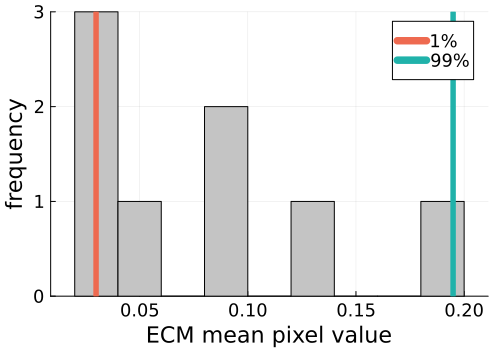

In [61]:
# plot histogram of mean pixel values
p = histogram(ECM_mean_inv, label = "", 
    xlabel = "ECM mean pixel value", ylabel = "frequency", bins = 9,
    guidefontsize = 15, xtickfontsize = 12, ytickfontsize = 12, legendfontsize = 12,
    color = "grey77",
    size = (500, 350))
vline!(p, [low, low], label = "1%", linewidth = 5, color = "coral2")
vline!(p, [high, high], label = "99%", linewidth = 5, color = "lightseagreen")
#savefig("figures/histogram_ECM_pixels.pdf")
plot(p)

Determine the function that computes the number of points sampled from each image. 

Here, we use a linear function by specifying the number of points to sample at "low" ECM content image and "high" ECM content

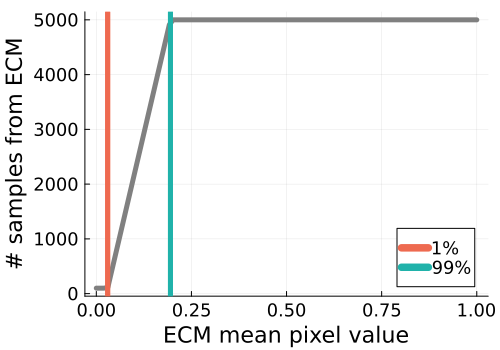

In [62]:
# plot the number of points to be sampled as a function of ECM mean pixel value
min_sample = 100 
max_sample = 5000

x = range(0, 1, length = 100)
y = n_ECM_samples.(x, low, high, min_sample, max_sample)
p = plot(x, y, label = "", 
        xlabel = "ECM mean pixel value", ylabel ="# samples from ECM",
        color = "grey",
        linewidth = 5,
        legend = :bottomright,
        guidefontsize = 15, xtickfontsize = 12, ytickfontsize = 12, legendfontsize = 12,
        size = (500, 350),
        )
vline!(p, [low, low], label = "1%", linewidth = 5, color = "coral2")
vline!(p, [high, high], label = "99%", linewidth = 5, color = "lightseagreen")
#savefig("figures/n_ECM_function.pdf")
plot(p)

## 2(b) Sample points from all ECM images

In [64]:
ECM_directory = "example_images/"
min_sample = 100
max_sample = 5000 
sample_CSV_directory = "example_pointclouds/pointcloud_CSV/"
sample_plot_directory = "example_pointclouds/pointcloud_plots/"
sample_points_from_ECM_directory(ECM_directory, min_sample, max_sample, low, high,
                                sample_CSV_directory = sample_CSV_directory, sample_plot_directory = sample_plot_directory)

The sampled pointclouds are saved in `example_pointclouds`.
